# Denoising images

# Modelling

> *All models are wrong, but some are useful.*
> 
> \- George Box

## What is an image

* Mathematicians like to think of images as vector-valued functions
* Computer scientists like to think of images as multi-dimensional arrays
* We can even think of images as graphs

For today, we focus on grey-scale images represented as 2D arrays $F \in \mathbb{R}^{n\times n}$ or 1D arrays $\mathbf{f}\in\mathbb{R}^{n^2}$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize


def circle_image(n, radius=0.35, supersample=1):
    """
    Sample the indicator function of a disk on an n x n grid.

    supersample=1 gives hard binary pixels.
    supersample>1 approximates pixel-area averaging, i.e. anti-aliasing.
    """
    m = n * supersample

    x = (np.arange(m) + 0.5) / m
    y = (np.arange(m) + 0.5) / m
    X, Y = np.meshgrid(x, y)

    disk = ((X - 0.5)**2 + (Y - 0.5)**2 <= radius**2).astype(float)

    if supersample == 1:
        return disk

    # average over supersample x supersample blocks
    return disk.reshape(n, supersample, n, supersample).mean(axis=(1, 3))


resolutions = [128, 64, 32, 16]

fig, axes = plt.subplots(2, len(resolutions), figsize=(12, 5))

for j, n in enumerate(resolutions):
    img_binary = circle_image(n, supersample=1)
    img_aa = circle_image(n, supersample=8)

    axes[0, j].imshow(img_binary, cmap="gray", vmin=0, vmax=1)
    axes[0, j].set_title(f"{n} x {n}, binary")
    axes[0, j].axis("off")

    axes[1, j].imshow(img_aa, cmap="gray", vmin=0, vmax=1)
    axes[1, j].set_title(f"{n} x {n}, anti-aliased")
    axes[1, j].axis("off")

plt.tight_layout()
plt.savefig('./figures/circles.png',dpi=300)
plt.close()

![](./figures/circles.png)

## Types of noise

* We can think of noise as any feature in the image that diminishes its scientific usefulness
* This could include measurement noise, distortions, pre-processing artifacts, quantization, ...
* We will focus on noise that can be modelled stochastically, as perturbation of underlying "clean" image.

**Additive Gaussian noise:**

$$f_i\sim N (\overline{f}_i,\sigma^2)$$

**Poisson noise:**

$$f\sim P(\overline{f}_i)$$

**Salt-and-Pepper:**

$$f_i = \begin{cases} 0 & \text{with probability } p/2 \\ 1 & \text{with probability } p/2\\ \overline{f}_i & \text{with probability } 1-p \end{cases}$$

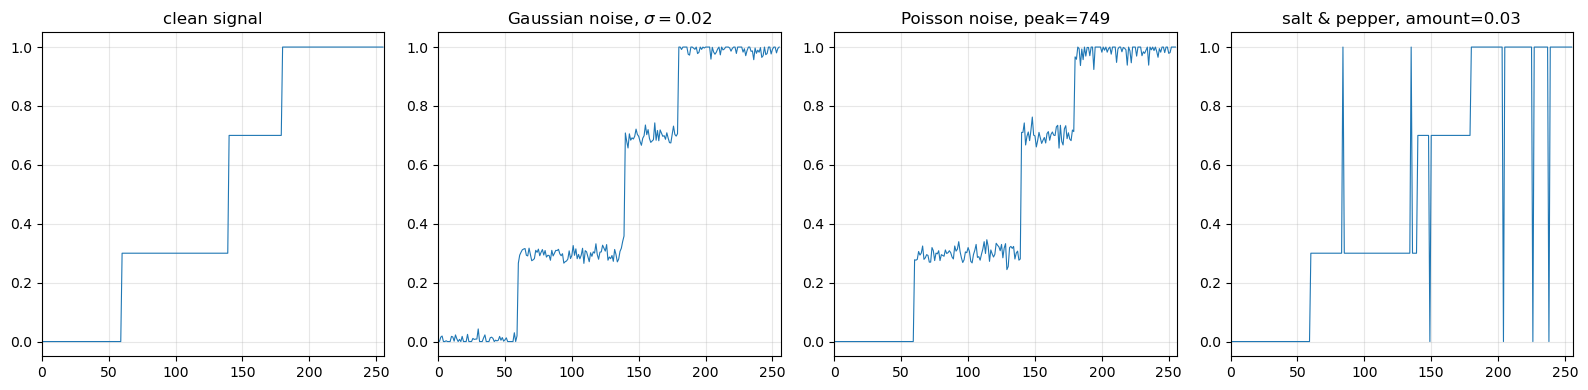

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from skimage.util import random_noise


# 1D step function
n = 256
u = np.zeros(n)
u[60:140] = 0.3
u[140:180] = 0.7
u[180:] = 1.0

rng = np.random.default_rng(42)

# 1. Additive Gaussian noise
sigma = 0.02
u_gauss = u + sigma * rng.standard_normal(n)
u_gauss = np.clip(u_gauss, 0, 1)

# 2. Poisson noise
# Match variance to Gaussian noise at u=0.3:
# Var(u_poisson) = u / peak_counts = sigma^2
peak_counts = int(0.3 / sigma**2)
counts = rng.poisson(peak_counts * u)
u_poisson = counts / peak_counts
u_poisson = np.clip(u_poisson, 0, 1)

# 3. Salt-and-pepper noise
amount = 0.03
u_sp = random_noise(u, mode="s&p", amount=amount, rng=42)


fig, axes = plt.subplots(1, 4, figsize=(16, 4))

signals = [u, u_gauss, u_poisson, u_sp]
titles = [
    "clean signal",
    f"Gaussian noise, $\\sigma={sigma}$",
    f"Poisson noise, peak={peak_counts}",
    f"salt & pepper, amount={amount}",
]

for ax, sig, title in zip(axes.flat, signals, titles):
    ax.plot(sig, linewidth=0.8)
    ax.set_title(title)
    ax.set_xlim(0, n)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./figures/noisy-line-profiles.png', dpi=300)
#plt.close()

![](./figures/noisy-line-profiles.png)

![]('./figures/noisy-line-profiles.png')

## How do we compare images?

* We need a way to judge the quality of an image. Which metric is suitable is highly application (and community) dependent
* We discern methods with and without a reference.
* Without a reference: resolution, contrast, ...
* With a reference: SNR, MSE, SSIM, ...

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, FancyBboxPatch

from skimage import data, img_as_float
from skimage.filters import gaussian
from skimage.metrics import (
    mean_squared_error,
    peak_signal_noise_ratio,
    structural_similarity,
)

# ---------------------------------------------------------
# Clean image
# ---------------------------------------------------------

u = img_as_float(data.camera())

# ---------------------------------------------------------
# Create degraded versions
# ---------------------------------------------------------

u_blur = gaussian(u, sigma=2)

rng = np.random.default_rng(0)
u_noise = np.clip(u + 0.08 * rng.standard_normal(u.shape), 0, 1)

u_bright = np.clip(1.25 * u, 0, 1)

images = [u, u_blur, u_noise, u_bright]
titles = [
    "Clean",
    "Blurred",
    "Gaussian noise",
    "Increased contrast",
]

# ---------------------------------------------------------
# Simple no-reference measures
# ---------------------------------------------------------

def contrast_std(img):
    return np.std(img)

def sharpness_gradient(img):
    gx, gy = np.gradient(img)
    return np.mean(np.sqrt(gx**2 + gy**2))


# ---------------------------------------------------------
# Compute all metrics
# ---------------------------------------------------------

all_metrics = []
for img in images:
    contrast = contrast_std(img)
    sharpness = sharpness_gradient(img)
    mse = mean_squared_error(u, img)
    with np.errstate(divide='ignore', invalid='ignore'):
        psnr = peak_signal_noise_ratio(u, img, data_range=1)
    ssim = structural_similarity(u, img, data_range=1)

    all_metrics.append({
        'contrast': contrast,
        'sharpness': sharpness,
        'mse': mse,
        'psnr': psnr if np.isfinite(psnr) else 50,  # Use 50 as max PSNR for perfect match
        'ssim': ssim
    })

# Normalize metrics for visualization
ref_contrast = all_metrics[0]['contrast']
ref_sharpness = all_metrics[0]['sharpness']
ref_mse = all_metrics[0]['mse'] if all_metrics[0]['mse'] > 0 else 1
ref_psnr = all_metrics[0]['psnr']
ref_ssim = all_metrics[0]['ssim']

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, axes = plt.subplots(
    2,
    4,
    figsize=(15, 5),
    gridspec_kw={'height_ratios': [2.4, 0.55]},
)

bar_labels = ['Contrast', 'Sharpness', 'MSE', 'PSNR', 'SSIM']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, (img, title) in enumerate(zip(images, titles)):
    metrics = all_metrics[i]

    # Top row: images
    ax_img = axes[0, i]
    ax_img.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax_img.set_title(title)
    ax_img.axis("off")
    ax_img.set_facecolor('none')

    # Bottom row: bar charts
    ax_bar = axes[1, i]
    ax_bar.set_facecolor('none')

    # Normalize metrics to 0-1 range for visualization
    bar_values = [
        metrics['contrast'] / ref_contrast,
        metrics['sharpness'] / ref_sharpness,
        1 - np.clip(metrics['mse'] / ref_mse, 0, 1),  # invert MSE (lower is better)
        metrics['psnr'] / ref_psnr,
        metrics['ssim'] / ref_ssim
    ]

    ax_bar.bar(range(len(bar_labels)), bar_values, color=colors, width=0.62)
    ax_bar.set_xticks([])
    ax_bar.set_ylim(0, 1.1)
    ax_bar.set_yticks([])
    ax_bar.spines['left'].set_visible(False)
    ax_bar.spines['top'].set_visible(False)
    ax_bar.spines['right'].set_visible(False)

legend_handles = [Patch(facecolor=c, edgecolor='none', label=l) for c, l in zip(colors, bar_labels)]
fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(bar_labels),
    frameon=False,
    bbox_to_anchor=(0.5, -0.02),
    columnspacing=1.2,
    handlelength=1.0,
)

# Extra horizontal spacing prevents group panels from touching.
plt.tight_layout(rect=[0, 0.07, 1, 1])
fig.subplots_adjust(wspace=0.24, hspace=0.02)

# Add light rounded panels so each image + chart reads as one visual group.
for i in range(len(images)):
    pos_top = axes[0, i].get_position()
    pos_bottom = axes[1, i].get_position()

    x0 = min(pos_top.x0, pos_bottom.x0) - 0.003
    y0 = min(pos_top.y0, pos_bottom.y0) - 0.006
    x1 = max(pos_top.x1, pos_bottom.x1) + 0.003
    y1 = max(pos_top.y1, pos_bottom.y1) + 0.006

    panel = FancyBboxPatch(
        (x0, y0),
        x1 - x0,
        y1 - y0,
        boxstyle="round,pad=0.003,rounding_size=0.01",
        transform=fig.transFigure,
        facecolor="#f7f7f7",
        edgecolor="#c8c8c8",
        linewidth=1.0,
        zorder=-1,
    )
    fig.add_artist(panel)

plt.savefig('./figures/image-metrics.png', dpi=300, bbox_inches='tight')
plt.close(fig)

![](./figures/image-metrics.png)

# Getting rid of noise

> *Getting rid of noise is easy, it's keeping the useful bits that is hard.*
>
> \- This lecture

# Bias and variance

Suppose we have a noisy image $F^\delta$ and a method to denoise the image:
$$\widetilde{F} = \mathcal{R}(F^\delta),$$
we want to study how well it approximates an underlying clean image $F$.

It is often usefull to think of the error in terms of the bias and variance:
$$\mathcal{D}\bigl(\mathcal{R}(F^\delta),F\bigr) \leq \underbrace{\mathcal{D}\bigl(\mathcal{R}(F),F\bigr)}_{\text{bias}} + \underbrace{\mathcal{D}\bigl(\mathcal{R}(F^\delta),\mathcal{R}(F)\bigr)}_{\text{variance}}.$$

## Filtering and smoothing

* Local (Gaussian) smoothing
* Median filtering
* Frequency-domain filtering

**Local (Gaussian) smoothing:**

* Noise fluctuates on a pixel-by-pixel basis, while the underlying image is highly correlated
* This motivates local smoothing $$\widetilde{F}_{ij} = \sum_{k\ell} G_{|i-k|,|j-\ell|} F_{k\ell}^\delta$$
* For example: $G_{pq} = c\cdot \exp(-(\alpha p^2 + \beta q^2) )$

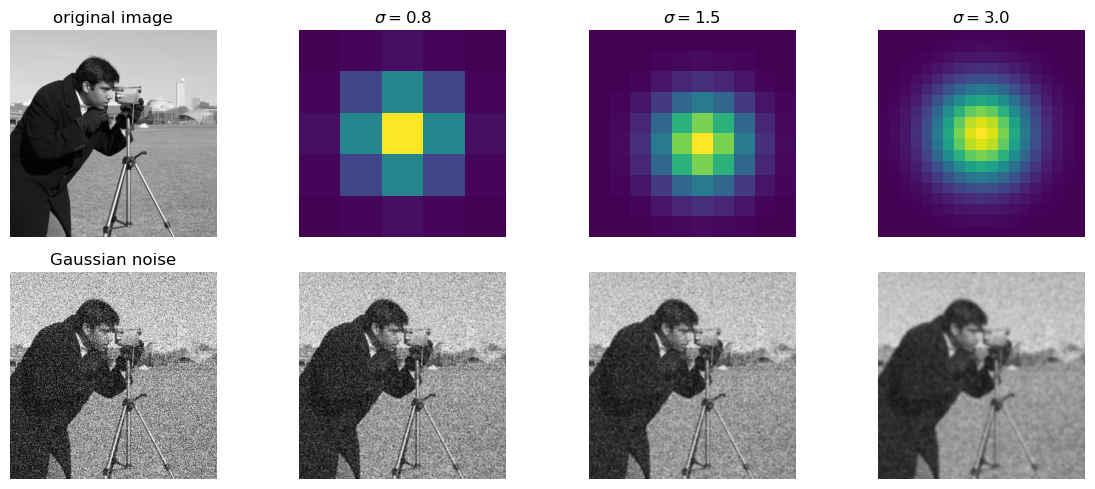

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import convolve2d

from skimage import data, img_as_float
from skimage.filters import gaussian
from skimage.util import random_noise


# ---------------------------------------------------------
# Clean image
# ---------------------------------------------------------

u = img_as_float(data.camera())

rng = np.random.default_rng(0)

# ---------------------------------------------------------
# Three noise models
# ---------------------------------------------------------

sigma = 0.30
u_gauss = np.clip(
    u + sigma * rng.standard_normal(u.shape),
    0, 1
)

peak = 10
counts = rng.poisson(peak * u)
u_poisson = np.clip(counts / peak, 0, 1)

u_sp = random_noise(
    u,
    mode="s&p",
    amount=0.08,
    rng=0
)

noisy_images = [
    u,
    u_gauss,
    #u_poisson,
    #u_sp,
]

row_titles = [
    "clean",
    "Gaussian noise",
    #"Poisson noise",
    #"salt & pepper",
]

# ---------------------------------------------------------
# Gaussian kernels
# ---------------------------------------------------------

sigmas = [0.8, 1.5, 3.0]

kernels = []

for s in sigmas:
    size = int(6 * s + 1)

    x = np.arange(size) - size // 2
    X, Y = np.meshgrid(x, x)

    k = np.exp(-(X**2 + Y**2) / (2 * s**2))
    k /= k.sum()

    kernels.append(k)

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, axes = plt.subplots(
    len(noisy_images), len(kernels)+1,
    figsize=(12, 12)
)

# ---------------------------------------------------------
# First row: kernels
# ---------------------------------------------------------

axes[0, 0].imshow(u, cmap="gray", vmin=0, vmax=1)
axes[0, 0].set_title("original image")
axes[0, 0].axis("off")

for j, (k, s) in enumerate(zip(kernels, sigmas), start=1):

    axes[0, j].imshow(k, cmap="viridis")
    axes[0, j].set_title(f"$\\sigma={s}$")
    axes[0, j].axis("off")

# ---------------------------------------------------------
# Remaining rows
# ---------------------------------------------------------

for i, (img, row_title) in enumerate(
    zip(noisy_images[1:], row_titles[1:]),
    start=1
):

    # noisy image
    axes[i, 0].imshow(img, cmap="gray", vmin=0, vmax=1)
    axes[i, 0].set_title(row_title)
    axes[i, 0].axis("off")

    # filtered versions
    for j, s in enumerate(sigmas, start=1):

        filtered = gaussian(img, sigma=s)

        axes[i, j].imshow(
            filtered,
            cmap="gray",
            vmin=0,
            vmax=1
        )

        axes[i, j].axis("off")

#fig.set_figwidth(4)
fig.set_figheight(5)
plt.tight_layout()
plt.savefig('./figures/gaussian-smoothing.png',dpi=300)
plt.close()

![](./figures/gaussian-smoothing.png)

**Median filter**

A disadvantage of the previous approach is that it also smoothes out edges in the image. An alternative method is the *median filter*, which replaces the value in each pixel with the median of its neighborhood (in stead of the weighted mean).

/var/folders/g2/z5xkdjy513j76nkltmmxlkp00000gn/T/ipykernel_9727/2555939019.py:35: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  median(u_noisy, footprint=square(s))


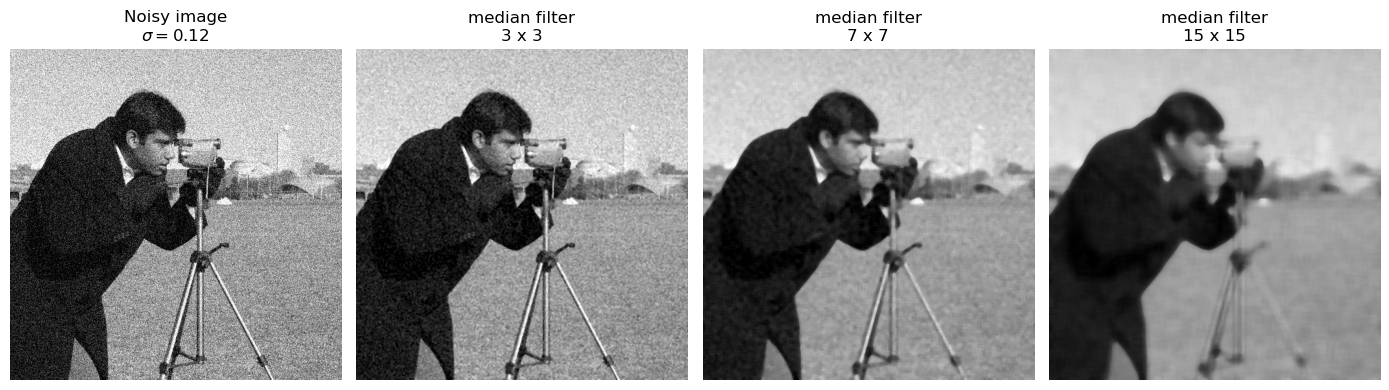

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, img_as_float
from skimage.filters import median
from skimage.morphology import square


# ---------------------------------------------------------
# Clean image
# ---------------------------------------------------------

u = img_as_float(data.camera())

# ---------------------------------------------------------
# Add Gaussian noise
# ---------------------------------------------------------

rng = np.random.default_rng(0)

sigma = 0.12

u_noisy = np.clip(
    u + sigma * rng.standard_normal(u.shape),
    0, 1
)

# ---------------------------------------------------------
# Median filter sizes
# ---------------------------------------------------------

sizes = [3, 7, 15]

filtered_images = [
    median(u_noisy, footprint=square(s))
    for s in sizes
]

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1, 4,
    figsize=(14, 7)
)

# ---------------------------------------------------------
# Top row: noisy image + footprints
# ---------------------------------------------------------

axes[0].imshow(u_noisy, cmap="gray", vmin=0, vmax=1)
axes[0].set_title(
    f"Noisy image\n$\\sigma={sigma}$"
)
axes[0].axis("off")

for j, s in enumerate(sizes, start=1):

    axes[j].set_title(
        f"median footprint\n{s} x {s}"
    )

    axes[j].axis("off")

# ---------------------------------------------------------
# Bottom row: filtered images
# ---------------------------------------------------------


for j, (img, s) in enumerate(
    zip(filtered_images, sizes),
    start=1
):

    axes[j].imshow(
        img,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[j].set_title(
        f"median filter\n{s} x {s}"
    )

    axes[j].axis("off")

plt.tight_layout()
plt.savefig('./figures/median-smoothing.png',dpi=300)
plt.close()

![](./figures/median-smoothing.png)

**Fourier domain**
An alternative view on the Gaussian filter is to consider it as weighting in the Fourier domain:

> **Convolution theorem:**
> Convolution in the spatial domain is equivalent to multiplication in the Fourier domain

This enables to efficiently filter large images with a wide variety of filters.

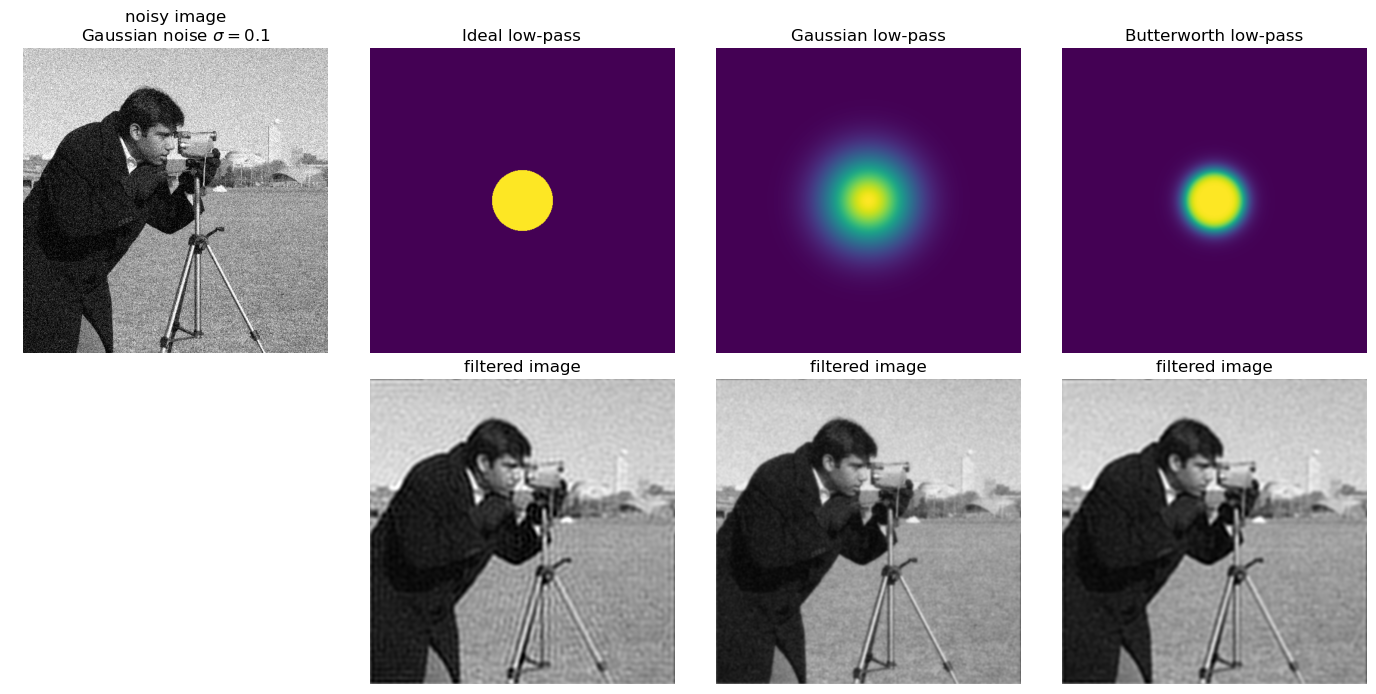

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, img_as_float


# ---------------------------------------------------------
# Clean image + Gaussian noise
# ---------------------------------------------------------

u = img_as_float(data.camera())

rng = np.random.default_rng(0)

sigma = 0.10

u_noisy = np.clip(
    u + sigma * rng.standard_normal(u.shape),
    0, 1
)

# ---------------------------------------------------------
# Fourier transform
# ---------------------------------------------------------

F = np.fft.fftshift(np.fft.fft2(u_noisy))

n, m = u.shape

x = np.linspace(-1, 1, m)
y = np.linspace(-1, 1, n)

X, Y = np.meshgrid(x, y)

R = np.sqrt(X**2 + Y**2)

# ---------------------------------------------------------
# Three classical low-pass filters
# ---------------------------------------------------------

cutoff = 0.20
order = 4

# 1. Ideal low-pass
H_ideal = (R <= cutoff).astype(float)

# 2. Gaussian low-pass
H_gaussian = np.exp(-(R**2) / (2 * cutoff**2))

# 3. Butterworth low-pass
H_butterworth = 1 / (
    1 + (R / cutoff)**(2 * order)
)

filters = [
    ("Ideal low-pass", H_ideal),
    ("Gaussian low-pass", H_gaussian),
    ("Butterworth low-pass", H_butterworth),
]

# ---------------------------------------------------------
# Apply filters
# ---------------------------------------------------------

results = []

for name, H in filters:

    F_filtered = H * F

    u_filtered = np.real(
        np.fft.ifft2(
            np.fft.ifftshift(F_filtered)
        )
    )

    results.append((name, H, u_filtered))

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, axes = plt.subplots(
    2, 4,
    figsize=(14, 7)
)

# ---------------------------------------------------------
# Row 1: noisy image + filters
# ---------------------------------------------------------

axes[0, 0].imshow(
    u_noisy,
    cmap="gray",
    vmin=0,
    vmax=1
)

axes[0, 0].set_title(
    f"noisy image\nGaussian noise $\\sigma={sigma}$"
)

axes[0, 0].axis("off")

for j, (name, H, _) in enumerate(results, start=1):

    axes[0, j].imshow(
        H,
        cmap="viridis"
    )

    axes[0, j].set_title(name)
    axes[0, j].axis("off")

# # ---------------------------------------------------------
# # Row 2: filter transfer functions (1D cross-section)
# # ---------------------------------------------------------

# r = np.linspace(0, 1, 500)

# H1 = (r <= cutoff).astype(float)
# H2 = np.exp(-(r**2) / (2 * cutoff**2))
# H3 = 1 / (1 + (r / cutoff)**(2 * order))

# axes[1, 0].axis("off")

# axes[1, 1].plot(r, H1)
# axes[1, 1].set_title("Ideal response")
# axes[1, 1].set_ylim(-0.05, 1.05)

# axes[1, 2].plot(r, H2)
# axes[1, 2].set_title("Gaussian response")
# axes[1, 2].set_ylim(-0.05, 1.05)

# axes[1, 3].plot(r, H3)
# axes[1, 3].set_title("Butterworth response")
# axes[1, 3].set_ylim(-0.05, 1.05)

# ---------------------------------------------------------
# Row 3: filtered images
# ---------------------------------------------------------

axes[1, 0].axis("off")

for j, (name, _, img) in enumerate(results, start=1):

    axes[1, j].imshow(
        img,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[1, j].set_title("filtered image")
    axes[1, j].axis("off")

# # ---------------------------------------------------------
# # Row 4: Fourier magnitude spectra
# # ---------------------------------------------------------

# axes[3, 0].imshow(
#     np.log1p(np.abs(F)),
#     cmap="magma"
# )

# axes[3, 0].set_title("Fourier spectrum")
# axes[3, 0].axis("off")

# for j, (_, H, _) in enumerate(results, start=1):

#     spectrum = np.log1p(np.abs(H * F))

#     axes[3, j].imshow(
#         spectrum,
#         cmap="magma"
#     )

#     axes[3, j].set_title("filtered spectrum")
#     axes[3, j].axis("off")

plt.tight_layout()
plt.savefig('./figures/fourier-smoothing.png',dpi=300)
plt.close()

![](./figures/fourier-smoothing.png)

## Transform-domain methods

So far, we have treated image in the natural pixel-basis and the Fourier basis. We have also seen both linear and non-linear filters. These ideas can be extended to transform-domain filters.

**Wavelet transform**

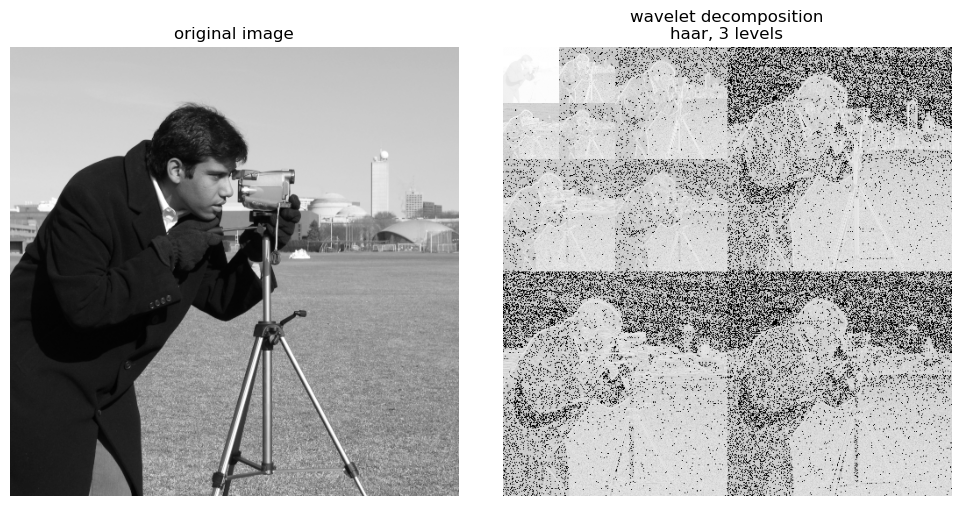

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import data, img_as_float
from skimage.restoration import denoise_wavelet


# Requires PyWavelets:
# pip install PyWavelets
import pywt


# ---------------------------------------------------------
# Clean image
# ---------------------------------------------------------

u = img_as_float(data.camera())

# ---------------------------------------------------------
# Wavelet decomposition
# ---------------------------------------------------------

wavelet = "haar"
level = 3

coeffs = pywt.wavedec2(u, wavelet=wavelet, level=level)

# coeffs[0] contains the coarse approximation.
# coeffs[1:] contain detail coefficients:
# horizontal, vertical, diagonal details at each scale.

arr, coeff_slices = pywt.coeffs_to_array(coeffs)

# ---------------------------------------------------------
# Plot wavelet coefficient image
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(u, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("original image")
axes[0].axis("off")

axes[1].imshow(np.log(abs(arr)+1e-16), cmap="gray")
axes[1].set_title(
    f"wavelet decomposition\n{wavelet}, {level} levels"
)
axes[1].axis("off")

plt.tight_layout()
plt.show()
plt.close()

**Singular value decomposition**

## Variational denoising

Explicitly model the trade-off between bias and variance, and minimize it:
$$\min_{F} ...$$
The trick is to find the "right" value for $\lambda$.

Many of the approaches mentioned earlier can be modelled in this way. We focus here on Total Variation denoising

In [1]:
# TV example

TV example

## Beyond

* Patches
* Dictionary learning
* Deep learning
* ...

# Wrap-up

* Whichever method you use, it strikes a balance between bias and variance
* Many well-understood classical methods for denoising exist -> try those first!
* If you have training data, a next step could be to finetine a classical method to it (filter choice, parameter tuning, freeform learned filter)